## Emotion Music Tagger

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Models Selection & Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Machine Learning - Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

# Utilities 
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(f'All libraries imported successfully')

All libraries imported successfully


In [3]:
# Load dataset
df = pd.read_csv('./278k_labelled_uri.csv')

print(f'Dataset loaded successfully')

Dataset loaded successfully


### 1. Data Inspection

In [4]:
# Check current shape
print(f'{df.shape}')

(277938, 15)


In [5]:
# Display first 5 rows
df.head() 

,Unnamed: 0.1,Unnamed: 0,duration (ms),danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spec_rate,labels,uri
0,0,0,195000.0,0.611,0.614,-8.815,0.0672,0.0169,0.000794,0.7530,0.520,128.050,3.446154e-07,2,spotify:track:3v6sBj3swihU8pXQQHhDZo
1,1,1,194641.0,0.638,0.781,-6.848,0.0285,0.0118,0.009530,0.3490,0.250,122.985,1.464234e-07,1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO
2,2,2,217573.0,0.560,0.810,-8.029,0.0872,0.0071,0.000008,0.2410,0.247,170.044,4.007850e-07,1,spotify:track:2CY92qejUrhyPUASawNVRr
3,3,3,443478.0,0.525,0.699,-4.571,0.0353,0.0178,0.000088,0.0888,0.199,92.011,7.959809e-08,0,spotify:track:11BPfwVbB7vok7KfjBeW4k
4,4,4,225862.0,0.367,0.771,-5.863,0.1060,0.3650,0.000001,0.0965,0.163,115.917,4.693131e-07,1,spotify:track:3yUJKPsjvThlcQWTS9ttYx


In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277938 entries, 0 to 277937
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      277938 non-null  int64  
 1   Unnamed: 0        277938 non-null  int64  
 2   duration (ms)     277938 non-null  float64
 3   danceability      277938 non-null  float64
 4   energy            277938 non-null  float64
 5   loudness          277938 non-null  float64
 6   speechiness       277938 non-null  float64
 7   acousticness      277938 non-null  float64
 8   instrumentalness  277938 non-null  float64
 9   liveness          277938 non-null  float64
 10  valence           277938 non-null  float64
 11  tempo             277938 non-null  float64
 12  spec_rate         277938 non-null  float64
 13  labels            277938 non-null  int64  
 14  uri               277938 non-null  object 
dtypes: float64(11), int64(3), object(1)
memory usage: 31.8+ MB


In [7]:
# Statistic Summary 
df.describe()

,Unnamed: 0.1,Unnamed: 0,duration (ms),danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spec_rate,labels
count,277938.000000,277938.000000,2.779380e+05,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,2.779380e+05,277938.000000
mean,138968.500000,138968.500000,2.324961e+05,0.552583,0.556866,-10.363654,0.087913,0.386583,0.255044,0.189217,0.449602,119.196002,4.754654e-07,1.179101
std,80233.933896,80233.933896,1.171830e+05,0.188905,0.279681,6.672049,0.112500,0.364504,0.373745,0.163596,0.267471,30.462256,9.190229e-07,1.021033
min,0.000000,0.000000,6.706000e+03,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,69484.250000,69484.250000,1.720130e+05,0.431000,0.342000,-12.747000,0.035900,0.033800,0.000000,0.096200,0.220000,95.072250,1.531461e-07,0.000000
50%,138968.500000,138968.500000,2.131055e+05,0.571000,0.591000,-8.397000,0.047100,0.262000,0.001090,0.121000,0.434000,119.940000,2.345459e-07,1.000000
75%,208452.750000,208452.750000,2.648660e+05,0.693000,0.792000,-5.842000,0.082200,0.754000,0.645000,0.227000,0.665000,138.869750,4.449937e-07,2.000000
max,277937.000000,277937.000000,3.919895e+06,0.989000,1.000000,4.882000,0.965000,0.996000,1.000000,1.000000,1.000000,244.947000,5.971860e-05,3.000000


In [8]:
# Check Target Variable ('label') distribution
label_counts = df['labels'].value_counts().sort_index()

# Create readable labels
emotion_map = {0: 'Sad', 1:'Happy', 2:'Energetic', 3:'Calm'}
label_counts_rename = label_counts.rename(emotion_map)
print(label_counts_rename)

labels
Sad           82058
Happy        106429
Energetic     47065
Calm          42386
Name: count, dtype: int64


### 2. Data Cleaning

In [9]:
# Drop index artifacts and track identifier
columns_to_drop = ['Unnamed: 0', 'Unnamed: 0.1', 'duration (ms)', 'uri']

df_clean = df.drop(columns=columns_to_drop)

print(f'Old Dataset Shape:{df.shape}')
print(f'\nNew Dataset Shape:{df_clean.shape}')
print(f'- Dropped Columns: {columns_to_drop}')
print(f'- New Dataset Columns: {df_clean.columns.tolist()}') 

Old Dataset Shape:(277938, 15)

New Dataset Shape:(277938, 11)
- Dropped Columns: ['Unnamed: 0', 'Unnamed: 0.1', 'duration (ms)', 'uri']
- New Dataset Columns: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'spec_rate', 'labels']


In [10]:
# Missing Values
missing_values = df_clean.isnull().sum()

if missing_values.sum() == 0:
    print(f'No missing values found, dataset is complete')
else:
    print(f'Found {missing_values.sum()} missing values')
    print(f'\nColumns with missing values:')
    print(missing_values[missing_values > 0])

No missing values found, dataset is complete


In [11]:
# Duplicated Values
duplicate_values = df_clean.duplicated().sum()

if duplicate_values == 0:
    print(f'No duplicate rows found')
else:
    print(f'Found {duplicate_values} duplicated rows ({round((duplicate_values/len(df_clean)*100),2)}%)')
    df_clean = df_clean.drop_duplicates()

    print(f'ACTION: Duplicates removed')
    print(f'\nNew Dataset Shape: {df_clean.shape}')

Found 1679 duplicated rows (0.6%)
ACTION: Duplicates removed

New Dataset Shape: (276259, 11)


In [12]:
# Checking Spec_Rate 
print(f'Variance {df_clean['spec_rate'].var():.15f}')
print(f'Range (max-min): {df_clean['spec_rate'].max() - df_clean['spec_rate'].min():.10f}')

print(f'\nDECISION: Drop Spec Rate')
print(f'- Values are near-zero variance')
print(f'- Not in Spotify Official Audio Features Documentation')
print(f'- No clear relationship to emotion classification') 

Variance 0.000000000000847
Range (max-min): 0.0000597186

DECISION: Drop Spec Rate
- Values are near-zero variance
- Not in Spotify Official Audio Features Documentation
- No clear relationship to emotion classification


In [13]:
# Drop spec_rate
df_clean = df_clean.drop(columns=['spec_rate'])

print(f'New Dataset Shape: {df_clean.shape}')
print(f'New Dataset Columns: {list(df_clean.columns)}')

New Dataset Shape: (276259, 10)
New Dataset Columns: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'labels']


In [14]:
# Calculate correlation matrix (exclude label - target variable)
features_only = df_clean.copy().drop(columns=['labels'])
correlation_matrix = features_only.corr()

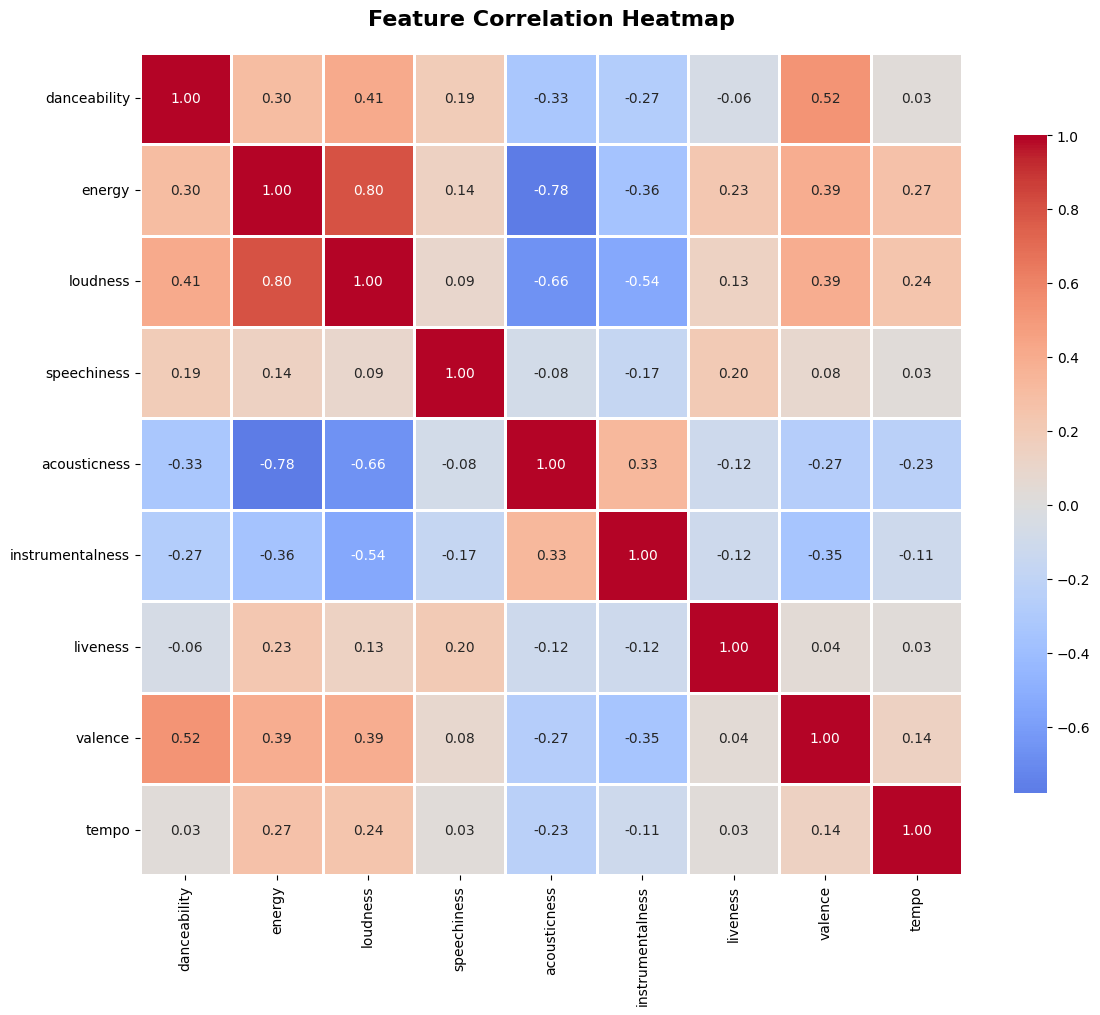

In [15]:
# Visualize Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidth=1, cbar_kws={'shrink': 0.8})

# Set title and labels
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [16]:
# Drop loudness due to multicollinearity
# loudness <-> energy = +0.8 correlation
df_clean = df_clean.drop(columns=['loudness'])

print(f'New Dataset Shape: {df_clean.shape}')
print(f'New Dataset Columns: {list(df_clean.columns)}')

New Dataset Shape: (276259, 9)
New Dataset Columns: ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'labels']


In [17]:
# Create boxplots for all features
features_only_boxplot = df_clean.copy().drop(columns=['labels']).columns

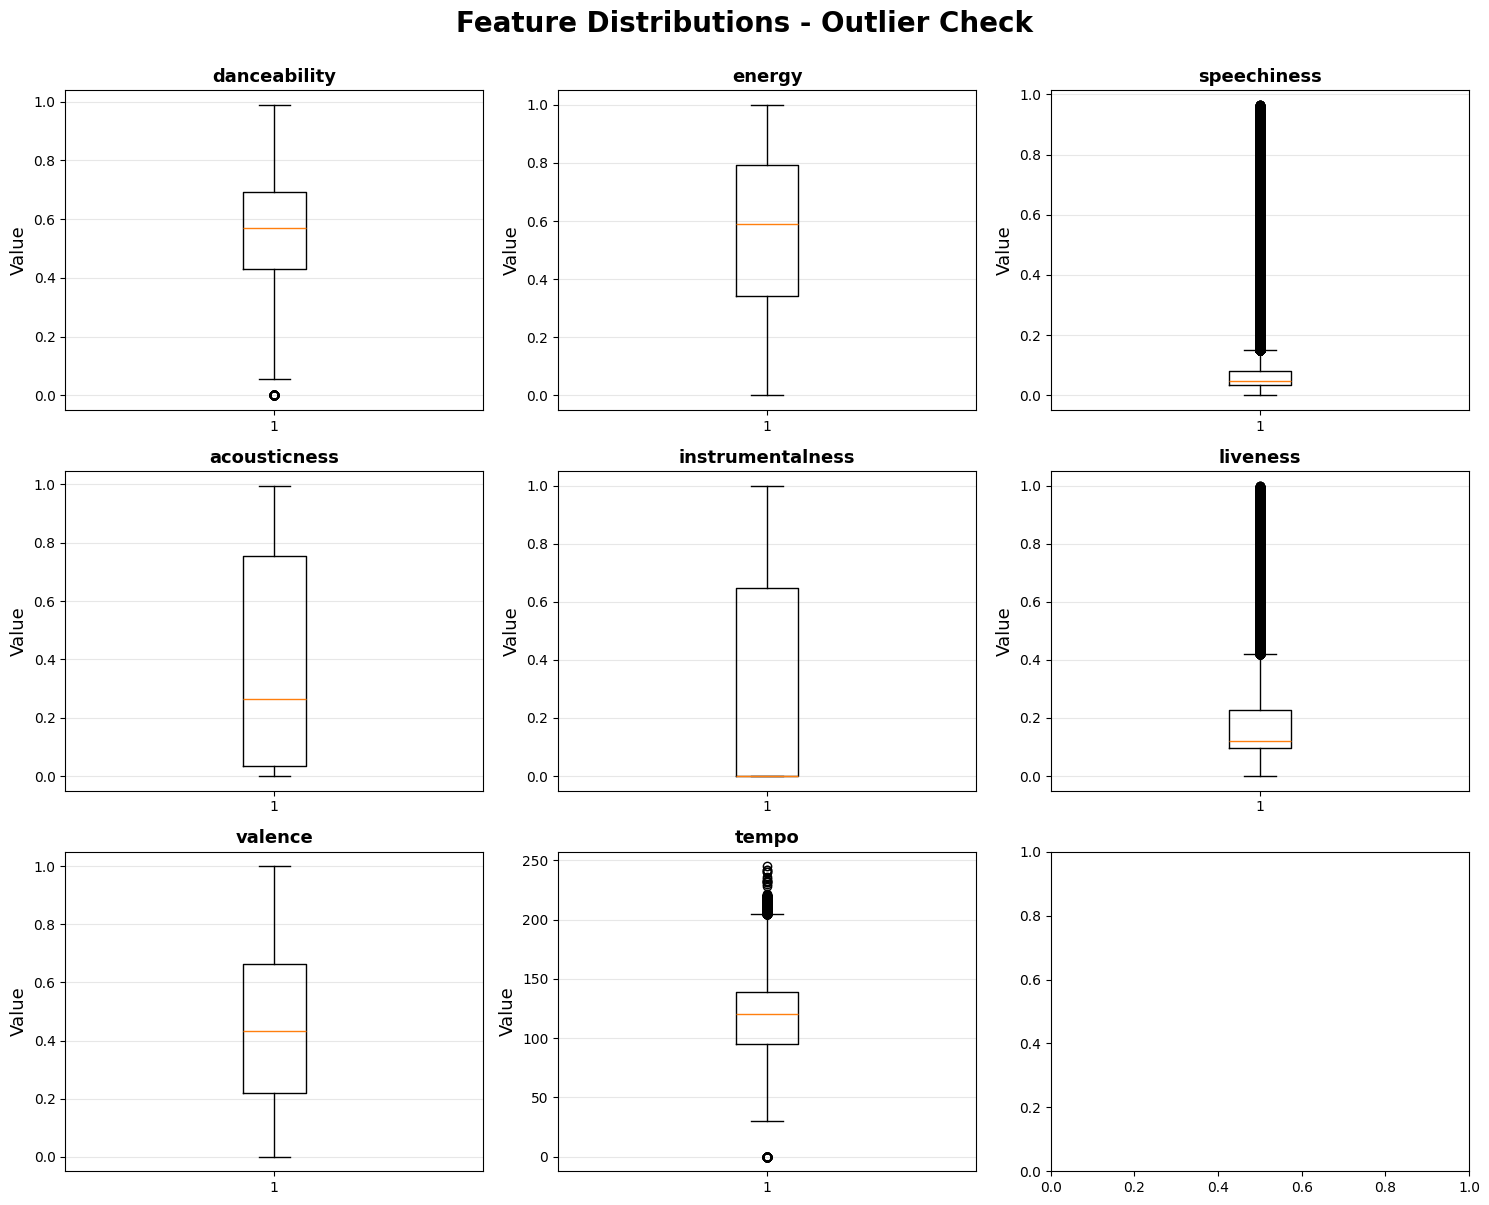

DECISION: Keep outliers as they represent genre diversity


In [18]:
# Visualize
fig, axes = plt.subplots(3, 3, figsize=(15,12))
axes = axes.flatten() # to 1D array, read the rows

for idx, feature in enumerate(features_only_boxplot):
    axes[idx].boxplot(df_clean[feature], vert=True)
    # Set title and labels
    axes[idx].set_title(f'{feature}',fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(f'Value', fontsize=13)
    axes[idx].grid(axis='y', alpha=0.3)

# y sets the vertical position slightly higher to prevent outlap with subplots' title
# Design choice
plt.suptitle(f'Feature Distributions - Outlier Check',
            fontsize=20, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

# Analysis
print(f'DECISION: Keep outliers as they represent genre diversity')

In [19]:
# Final Dataset (after Data Cleaning)
X = df_clean.drop(columns=['labels'])
y = df_clean['labels']

print(f'Features (X) shape: {X.shape}')
print(f'Target variable (y) shape: {y.shape}')
print(f'\nFeature Columns: {list(X.columns)}')
print(f'\nTarget distribution:')
print(y.value_counts().sort_index())

Features (X) shape: (276259, 8)
Target variable (y) shape: (276259,)

Feature Columns: ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

Target distribution:
labels
0     81627
1    105728
2     46716
3     42188
Name: count, dtype: int64


### 3. Exploratory Data Analysis (EDA)

In [20]:
# Target Variable ('Label') Distribution
y_counts = y.value_counts().sort_index()

# Create readable labels
print(f'\nTarget Variable Distribution (Raw Values):')
emotion_map = {0: 'Sad', 1:'Happy', 2:'Energetic', 3:'Calm'}
emotion_rename = y_counts.rename(emotion_map).sort_values(ascending=False)
print(emotion_rename)

# Change to percentage distribution
print(f'\nTarget Variable Distribution (Percentage):')
emotion_percentages = (emotion_rename / len(y) * 100).round(2)
print(emotion_percentages)


Target Variable Distribution (Raw Values):
labels
Happy        105728
Sad           81627
Energetic     46716
Calm          42188
Name: count, dtype: int64

Target Variable Distribution (Percentage):
labels
Happy        38.27
Sad          29.55
Energetic    16.91
Calm         15.27
Name: count, dtype: float64


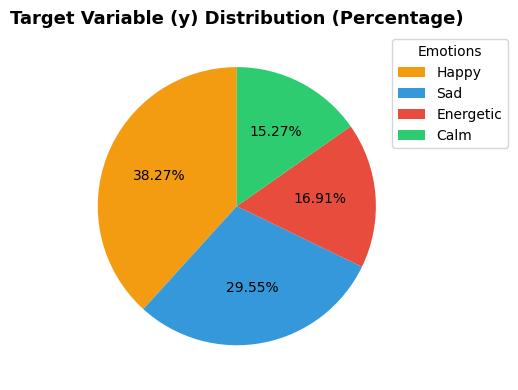

Analysis:
- Happy is the majority class (38.3%)
- Energetic and Calm are the minority class (~17% and 15% respectively)


In [21]:
# Visualisation
fig, axes = plt.subplots(figsize=(7,4))

# Pie Chart (Showing Percentage Distribution)
colors = ['#f39c12', '#3498db', '#e74c3c', '#2ecc71']
pie = axes.pie(emotion_percentages, labels=None, autopct='%1.2f%%',
                  colors=colors, startangle=90, radius=1)

plt.legend(emotion_percentages.index, title='Emotions', loc='upper right', bbox_to_anchor=(1.3,1))

plt.title(f'Target Variable (y) Distribution (Percentage)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Analysis
print(f'Analysis:')
print(f'- Happy is the majority class (38.3%)')
print(f'- Energetic and Calm are the minority class (~17% and 15% respectively)')

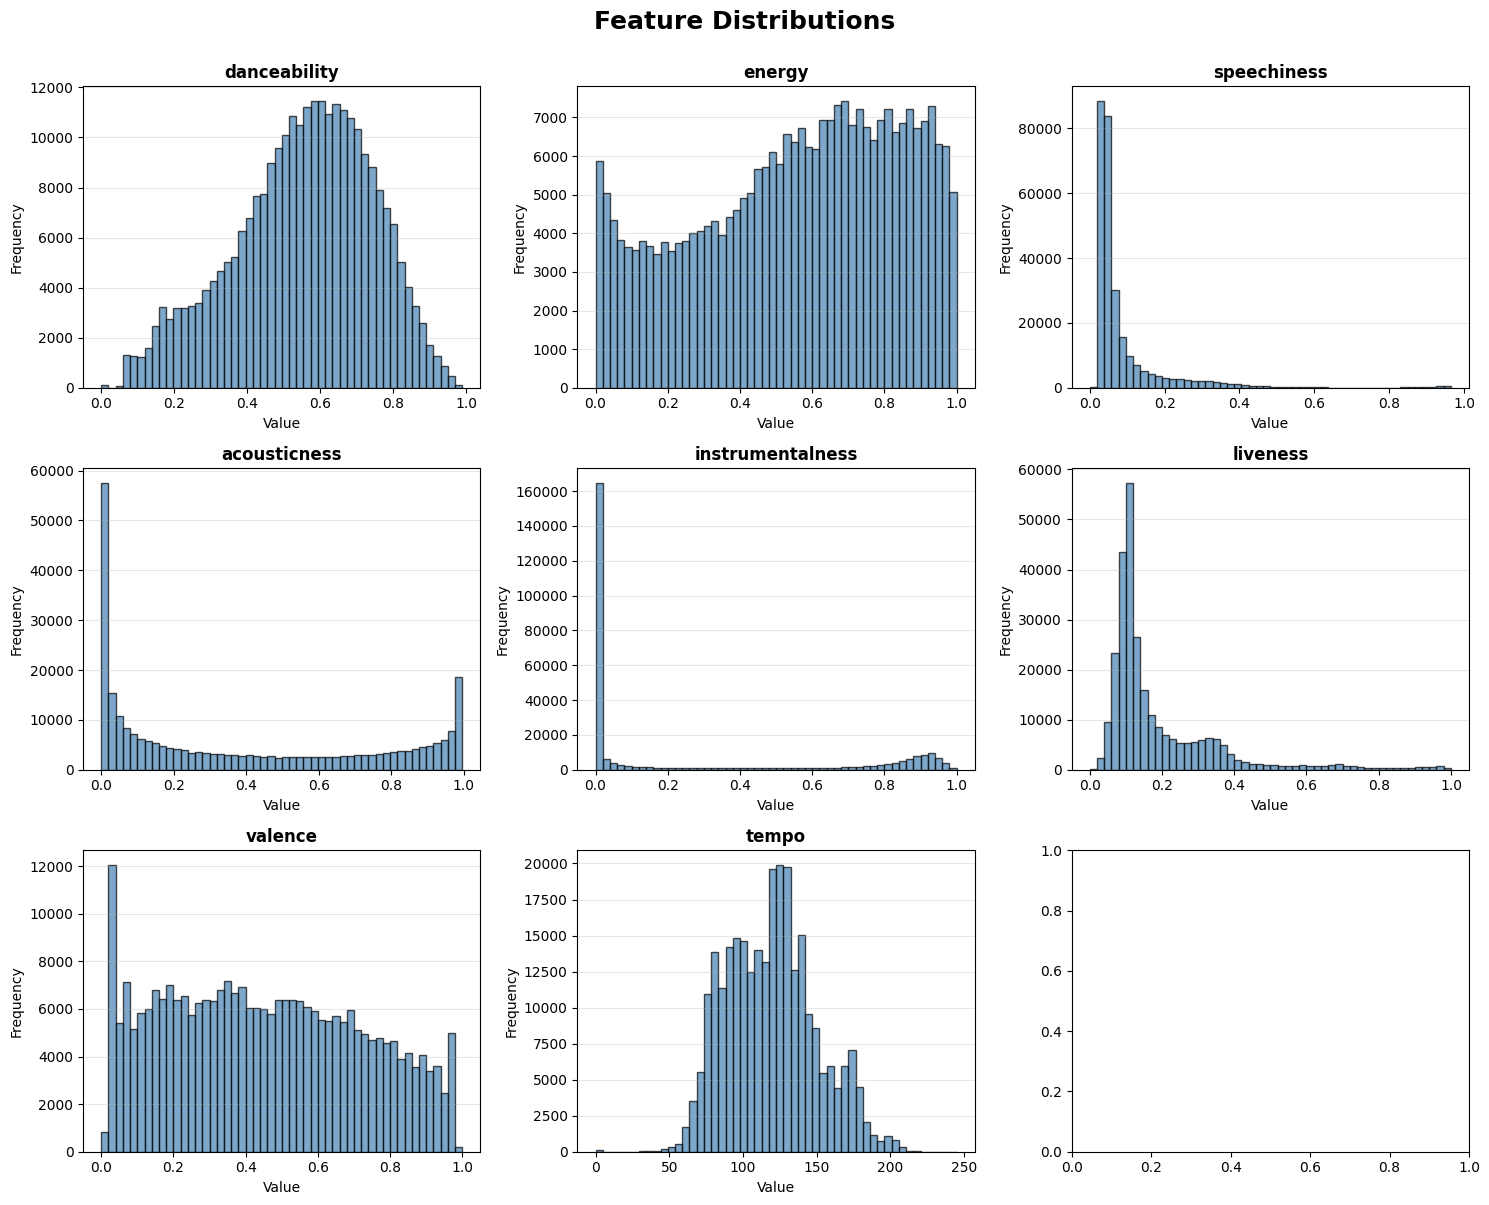

In [22]:
# Create histograms for all features
fig, axes = plt.subplots(3, 3, figsize=(15,12))
axes = axes.flatten() # Convert to 1D Array

for idx, feature in enumerate(X.columns):
    axes[idx].hist(X[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(f'Value')
    axes[idx].set_ylabel(f'Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle(f'Feature Distributions', fontsize=18, fontweight='bold', y=1)

plt.tight_layout()
plt.show()

In [23]:
# Combine featurs and target for grouping
df_analysis = X.copy()
df_analysis['emotion'] = y.replace(emotion_map)

# Create a list of names in the exact order
ordered_emotions = ['Sad', 'Happy', 'Energetic', 'Calm']

# Calculate mean values for each emotion (Original)
emotion_profiles = df_analysis.groupby('emotion').mean().reindex(ordered_emotions) # Without reindex, the emotions will sort by alphabetical order

print(f'{round(emotion_profiles, 2)}')

           danceability  energy  speechiness  acousticness  instrumentalness  \
emotion                                                                        
Sad                0.50    0.40         0.07          0.58              0.16   
Happy              0.68    0.69         0.11          0.21              0.11   
Energetic          0.50    0.87         0.10          0.03              0.18   
Calm               0.39    0.18         0.06          0.84              0.88   

           liveness  valence   tempo  
emotion                               
Sad            0.18     0.37  114.79  
Happy          0.19     0.60  121.20  
Energetic      0.24     0.44  134.01  
Calm           0.14     0.22  106.27  


In [24]:
# Calculate mean values for each emotion (Normalised)
# Normalised to show tempo (in BPM) and match with other 7 features
emotion_profiles_normalized = (emotion_profiles - emotion_profiles.min()) / (emotion_profiles.max() - emotion_profiles.min())

print(round(emotion_profiles_normalized,2))

           danceability  energy  speechiness  acousticness  instrumentalness  \
emotion                                                                        
Sad                0.40    0.31         0.17          0.68              0.06   
Happy              1.00    0.74         1.00          0.22              0.00   
Energetic          0.38    1.00         0.81          0.00              0.08   
Calm               0.00    0.00         0.00          1.00              1.00   

           liveness  valence  tempo  
emotion                              
Sad            0.38     0.41   0.31  
Happy          0.54     1.00   0.54  
Energetic      1.00     0.59   1.00  
Calm           0.00     0.00   0.00  


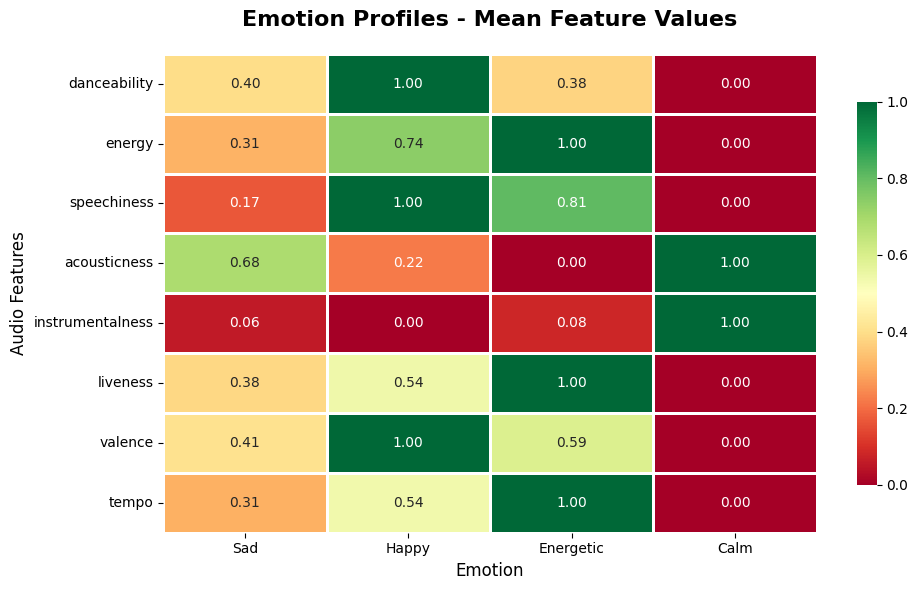

In [25]:
# Visualise Emotion Profiles with Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(emotion_profiles_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0.5, linewidths=1, cbar_kws={'shrink': 0.8})

# Set title and labels
plt.title(f'Emotion Profiles - Mean Feature Values', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'Emotion', fontsize=12)
plt.ylabel(f'Audio Features', fontsize=12)

plt.tight_layout()
plt.show()

In [26]:
# Modeling Analysis
print(f'Key Takeaway for Modeling')
print(f'- Sad\'s weak signature explains why it\'s likely the hardest class to predict')
print(f'- Happy, Energetic, Calm have clear profiles with multiple extreme values (1.00/0.00)')

Key Takeaway for Modeling
- Sad's weak signature explains why it's likely the hardest class to predict
- Happy, Energetic, Calm have clear profiles with multiple extreme values (1.00/0.00)


### 4. Feature Engineering and Modeling

In [27]:
# Three Way Holdout Split (70/15/15)
# Step 1: Split into 85% (training and validation) and 15% (test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)

In [28]:
# Step 2: Split the 85% into 70% train and 15% validation
# 15% of original = 0.15 / 0.85 = 0.1765 of temp
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

print(f'Train Set: {X_train.shape[0]} songs ({round(X_train.shape[0]/len(X)*100,1)}%)')
print(f'Validation Set: {X_val.shape[0]} songs ({round(X_val.shape[0]/len(X)*100,1)}%)')
print(f'Test Set: {X_test.shape[0]} songs ({round(X_test.shape[0]/len(X)*100,1)}%)')
print(f'Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} songs')

Train Set: 193374 songs (70.0%)
Validation Set: 41446 songs (15.0%)
Test Set: 41439 songs (15.0%)
Total: 276259 songs


In [29]:
# Create comparison DataFrame
# Make all training (70%), validation (15%) and test (15%) are equally distributed
split_comparison = pd.DataFrame({
    'Full Dataset': y.value_counts(normalize=True).sort_index()*100,
    'Train': y_train.value_counts(normalize=True).sort_index()*100,
    'Validation': y_val.value_counts(normalize=True).sort_index()*100,
    'Test': y_test.value_counts(normalize=True).sort_index()*100
})

# Rename emotion labels
emotion_map = {0: 'Sad', 1: 'Happy', 2: 'Energetic', 3: 'Calm'}
split_comparison.rename(index=emotion_map, inplace=True)

# Make values to 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(round(split_comparison, 2))

           Full Dataset  Train  Validation  Test
labels                                          
Sad               29.55  29.55       29.55 29.55
Happy             38.27  38.27       38.27 38.27
Energetic         16.91  16.91       16.91 16.91
Calm              15.27  15.27       15.27 15.27


In [30]:
# Initialize scaler
# Important for Logistic Regression later - cannot distinguish tempo BPM with 0-1 features
scaler = StandardScaler()

# Fit on train set and transform 
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test using TRAIN set statistics
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier inspection
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f'Scaled datasets ready:')
print(f'- X_train_scaled: {X_train_scaled.shape}')
print(f'- X_val_scaled: {X_val_scaled.shape}')
print(f'- X_test_scaled: {X_test_scaled.shape}')

Scaled datasets ready:
- X_train_scaled: (193374, 8)
- X_val_scaled: (41446, 8)
- X_test_scaled: (41439, 8)


### 5a. Model 1: Logistic Regression

In [31]:
# Initialize model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42, 
    class_weight='balanced'
)

In [32]:
# Train on scaled training data
lr_model.fit(X_train_scaled, y_train)

print(f'Training samples: {X_train_scaled.shape[0]}')
print(f'Features used: {X_train_scaled.shape[1]}')

Training samples: 193374
Features used: 8


In [33]:
# Predict on validation set 
y_val_pred = lr_model.predict(X_val_scaled)

# Calculate validation accuracy
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f'Validation Accuracy: {round(val_accuracy, 4)} ({round(val_accuracy*100,2)}%)')
print(f'\nTotal validation samples: {len(y_val)}')
print(f'Correctly predicted: {(y_val == y_val_pred).sum()}')
print(f'Incorrectly predicted: {(y_val != y_val_pred).sum()}')

Validation Accuracy: 0.8091 (80.91%)

Total validation samples: 41446
Correctly predicted: 33536
Incorrectly predicted: 7910


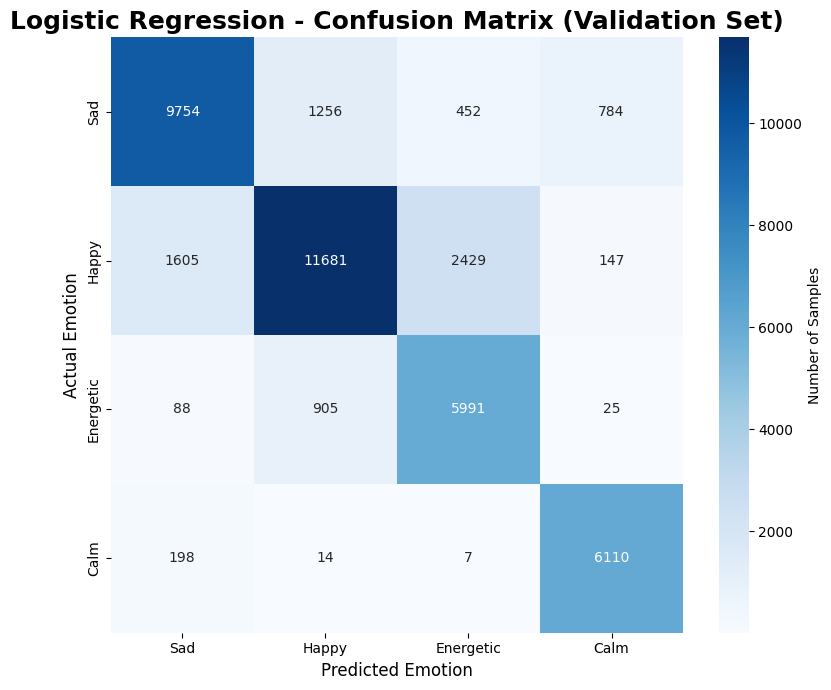

In [34]:
# Generate confusion matrix (Logistic Regression)
cm = confusion_matrix(y_val, y_val_pred)

# Create visualisation
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sad', 'Happy', 'Energetic', 'Calm'],
            yticklabels=['Sad', 'Happy', 'Energetic', 'Calm'],
            cbar_kws={'label': 'Number of Samples'}
           )

# Set title and labels
plt.title(f'Logistic Regression - Confusion Matrix (Validation Set)', fontsize=18, fontweight='bold')
plt.xlabel(f'Predicted Emotion', fontsize=12)
plt.ylabel(f'Actual Emotion', fontsize=12)

plt.tight_layout()
plt.show()

In [35]:
# Create per-class performance DataFrame for better visualisation
precision, recall, f1, support = precision_recall_fscore_support(
    y_val,
    y_val_pred,
    labels=[0,1,2,3]
)

# Save Logistic Regression findings to Dataframe
performance_df = pd.DataFrame({
    'Emotion': ['Sad', 'Happy', 'Energetic', 'Calm'],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print(performance_df.to_string(index=False, float_format='%.4f')) # Make it 4 decimal place, consistent with above

  Emotion  Precision  Recall  F1-Score  Support
      Sad     0.8376  0.7965    0.8165    12246
    Happy     0.8430  0.7364    0.7861    15862
Energetic     0.6747  0.8548    0.7542     7009
     Calm     0.8647  0.9654    0.9123     6329


### 5b. Model 2: Random Forest Classifier

In [36]:
# Initialize RF model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1 # Use ALL CPU cores for faster training
)

In [37]:
# Train on UNSCALED data (tree-based, scale-invariant)
# This will take some time, maybe around 10 seconds.
rf_model.fit(X_train, y_train)

print(f'Number of trees: {rf_model.n_estimators}')
print(f'Training samples: {X_train.shape[0]}')
print(f'Features used: {X_train.shape[1]}')

Number of trees: 100
Training samples: 193374
Features used: 8


In [38]:
# Predict on validation set (UNSCALED)
y_val_pred_rf = rf_model.predict(X_val)

# Calculate validation accuracy
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

# Compare to baseline
baseline_accuracy = 0.8091 # From Section 7.3
improvement = val_accuracy_rf - baseline_accuracy
target = 0.85 # Our target accuracy

print(f'LOGISTIC REGRESSION:')
print(f'Validation Accuracy: {round(baseline_accuracy, 4)} ({round(baseline_accuracy*100,2)}%)')

print(f'\nRANDOM FOREST CLASSIFIER:')
print(f'Validation Accuracy: {round(val_accuracy_rf, 4)} ({round(val_accuracy_rf*100, 2)}%)')
print(f'Improvement: {round(improvement, 4)} ({round(improvement*100, 2)}%)')

if val_accuracy_rf >= target:
    print(f'\nTarget achieved: >= 85% accuracy')
else:
    print(f'\nTarget not met:{round(target*100 - round(val_accuracy_rf*100,2), 2)} short of 85%')

LOGISTIC REGRESSION:
Validation Accuracy: 0.8091 (80.91%)

RANDOM FOREST CLASSIFIER:
Validation Accuracy: 0.9095 (90.95%)
Improvement: 0.1004 (10.04%)

Target achieved: >= 85% accuracy


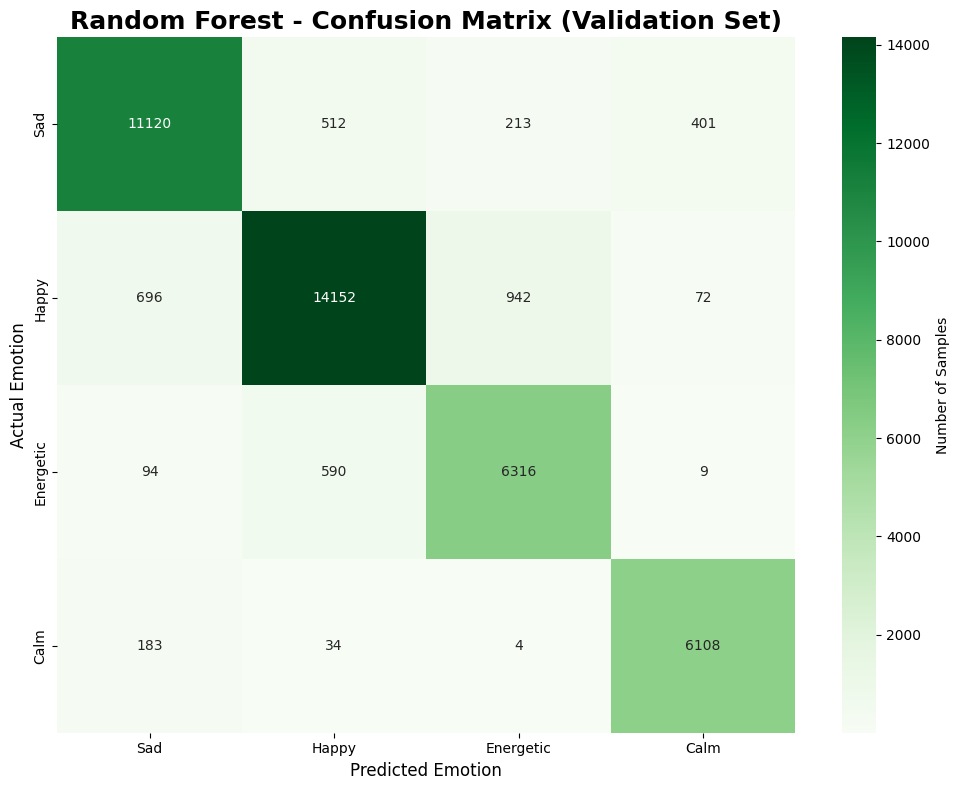

In [39]:
# Generate confusion matrix (Random Forest)
cm_rf = confusion_matrix(y_val, y_val_pred_rf)

# Create Visualisation
plt.figure(figsize=(10,8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', # Different color to distinguish from Logistic Regression
            xticklabels=['Sad', 'Happy', 'Energetic', 'Calm'],
            yticklabels=['Sad', 'Happy', 'Energetic', 'Calm'],
            cbar_kws={'label': 'Number of Samples'}
           )

# Set title and labels
plt.title(f'Random Forest - Confusion Matrix (Validation Set)', fontsize=18, fontweight='bold')
plt.xlabel(f'Predicted Emotion', fontsize=12)
plt.ylabel(f'Actual Emotion', fontsize=12)

plt.tight_layout()
plt.show()

In [40]:
# Compare diagonal values (True Positives) between models
# Logistic Regression confusion matrix (diagonal)
baseline_tp = np.diag(cm) 

# Random Forest Classifier confusion matrix (diagonal)
rf_tp = np.diag(cm_rf)

# Create comparison DataFrame
diagonal_comparison = pd.DataFrame({
    'Emotion': ['Sad', 'Happy', 'Energetic', 'Calm'],
    'Logistic Regression TP': baseline_tp,
    'Random Forest TP': rf_tp,
    'Improvement': rf_tp - baseline_tp
})

# Calculate percentage gain
diagonal_comparison['% Gain'] = (diagonal_comparison['Improvement'] / diagonal_comparison['Logistic Regression TP'] * 100)

print(f'\nDIAGONAL COMPARISON - TRUE POSITIVE CORRECT PREDICTIONS:')
print(diagonal_comparison.to_string(index=False, float_format='%.1f')) # Make it 1 decimal place


DIAGONAL COMPARISON - TRUE POSITIVE CORRECT PREDICTIONS:
  Emotion  Logistic Regression TP  Random Forest TP  Improvement  % Gain
      Sad                    9754             11120         1366    14.0
    Happy                   11681             14152         2471    21.2
Energetic                    5991              6316          325     5.4
     Calm                    6110              6108           -2    -0.0


In [41]:
# Create per-class performance DataFrame for better visualisation
precision_rf, recall_rf, f1_rf, support_rf = precision_recall_fscore_support(
    y_val,
    y_val_pred_rf, # Random Forest
    labels=[0,1,2,3]
)

# Save Random Forest Classifer findings to Dataframe
validation_df = pd.DataFrame({
    'Emotion': ['Sad', 'Happy', 'Energetic', 'Calm'],
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'Support': support_rf
})

# Logistic Regression metrics
baseline_f1 = [round(score, 4) for score in performance_df['F1-Score']] # List comprehension

# Compare per-class performance between models 
train_val_comparison = pd.DataFrame({
    'Emotion': ['Sad', 'Happy', 'Energetic', 'Calm'],
    'Logistic Regression F1': baseline_f1,
    'Random Forest F1': f1_rf,
    'Improvement': f1_rf - baseline_f1
})

print(train_val_comparison.to_string(index=False, float_format='%.4f')) # Make it 4 decimal place, consistent with above

  Emotion  Logistic Regression F1  Random Forest F1  Improvement
      Sad                  0.8165            0.9138       0.0973
    Happy                  0.7861            0.9086       0.1225
Energetic                  0.7542            0.8721       0.1179
     Calm                  0.9123            0.9456       0.0333


### 6. Test Set Evaluation (Selected Random Forest Classifier)

In [42]:
# Predict on test set 
y_test_pred = rf_model.predict(X_test)

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f'Validation Accuracy: {round(val_accuracy_rf, 4)} ({round(val_accuracy_rf*100, 2)}%)')
print(f'Test Accuracy: {round(test_accuracy, 4)} ({round(test_accuracy*100, 2)}%)')
print(f'\nTest samples (Full): {len(y_test)}')
print(f'Test Correctly predicted: {(y_test == y_test_pred).sum()}')
print(f'Test Incorrectly predicted: {(y_test != y_test_pred).sum()}')

Validation Accuracy: 0.9095 (90.95%)
Test Accuracy: 0.9132 (91.32%)

Test samples (Full): 41439
Test Correctly predicted: 37842
Test Incorrectly predicted: 3597


### 7. Feature Importance (Random Forest Classifier)

In [43]:
# Extract feature importance from Random Forest
feature_importance = rf_model.feature_importances_

# Create a DataFrame for better visualisation
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df

,Feature,Importance
0,energy,0.28
1,instrumentalness,0.26
2,acousticness,0.19
3,danceability,0.10
4,speechiness,0.06
5,valence,0.06
6,tempo,0.03
7,liveness,0.02


In [44]:
# Identify top 3 features
top_3_features = importance_df.head(3)['Feature'].tolist()
top_3_importance = importance_df.head(3)['Importance'].sum()

print(f'TOP 3 FEATURE IMPORTANCES:')
print(top_3_features)
print(f'\nCombined importance: {round(top_3_importance, 4)} ({round(top_3_importance*100)}%)')

TOP 3 FEATURE IMPORTANCES:
['energy', 'instrumentalness', 'acousticness']

Combined importance: 0.7359 (74%)


### 8. Find Top 3 feature for each emotion

In [45]:
# Create feature_emotion relationship table using training data
# Merge features and labels into one table for analysis
# We reset the index to ensure rows aligh perfectly after the shuffle
X_train_data = X_train.reset_index(drop=True).copy()
X_train_data['Emotion'] = y_train.values

# Calculate mean feature value per emotion
# Without reindex, the emotions will sort by alphabetical order
emotion_profiles = X_train_data.groupby('Emotion').mean()

# Rename the index to it's ordered emotions
emotion_profiles.index = ['Sad', 'Happy', 'Energetic', 'Calm']
emotion_profiles

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Sad,0.51,0.40,0.07,0.58,0.16,0.18,0.37,114.71
Happy,0.68,0.69,0.11,0.21,0.11,0.19,0.60,121.23
Energetic,0.50,0.87,0.10,0.03,0.18,0.24,0.44,133.96
Calm,0.39,0.18,0.06,0.84,0.88,0.14,0.22,106.19


In [46]:
# Create another SCALED VERSION to find the top 3 features for each emotion
X_train_data_scaled = X_train_scaled.reset_index(drop=True).copy()
X_train_data_scaled['Emotion'] = y_train.values

emotion_profiles_scaled = X_train_data_scaled.groupby('Emotion').mean()

emotion_profiles_scaled.index = ['Sad', 'Happy', 'Energetic', 'Calm']

In [47]:
# Using all the features above, identify the Top 3 for each emotions
# Without the scaled version, tempo will always be the top 3 features
# As they are in BPM, values of 100 over than other features within 0-1 range.
guidance_data = []

for emotion in emotion_profiles_scaled.index:
    # Find the row of feature values for that current emotion 
    row = emotion_profiles_scaled.loc[emotion]

    # Sort features from highest to lowest
    # Take the Top 3 names (.head(3).index) and convert to a list
    top_3 = row.sort_values(ascending=False).head(3).index.tolist()
    
    # Display result for each emotion
    print(emotion, top_3)

Sad ['acousticness', 'liveness', 'tempo']
Happy ['danceability', 'valence', 'energy']
Energetic ['energy', 'tempo', 'liveness']
Calm ['instrumentalness', 'acousticness', 'speechiness']


### 9. Real-World Validation

In [48]:
# 1. Load 1M Spotify track data
unseen_df = pd.read_csv('./Spotify_1Million_Tracks.csv')
unseen_df.head()

# Clean track_id format for matching
# Original 278k data has uri like 'spotify:track:ABC12345'
# Unseen 1M Track has track_id like 'ABC12345'
# Extract just the ID from original for comparison
original_id_clean = df['uri'].str.replace('spotify:track:', '')

print(f'ORIGINAL DATASET TRACK ID:') # The one we train the model
print(f'{len(original_id_clean)}')

print(f'\nUNSEEN DATASET TRACK ID:') # External, no target variable (y) - 'labels'
print(f'{len(unseen_df)}')

ORIGINAL DATASET TRACK ID:
277938

UNSEEN DATASET TRACK ID:
1048575


In [49]:
# 2. Remove training overlap (prevent data leakage)
# Check if Unseen track_id exist in Original
unseen_df['is_duplicate'] = unseen_df['track_id'].isin(original_id_clean)

duplicates = unseen_df['is_duplicate'].sum()
unseen_songs = unseen_df[unseen_df['is_duplicate'] == False].copy()

print(f'Duplicates found and removed: {duplicates}')
print(f'Truly unseen songs available: {len(unseen_songs)}')

Duplicates found and removed: 59148
Truly unseen songs available: 989427


In [50]:
# 3. Pick random unseen songs, 40 is changeable
np.random.seed(42)
random_5_songs = unseen_songs.sample(n=40, random_state=42)

print(f'LIST OF RANDOM SONGS:')
for idx, row in random_5_songs.iterrows():
    print(f'{row['track_id']} ({row['artist_name']})- {row['year']}')

features = ['danceability', 'energy', 'speechiness', 'acousticness', 
            'instrumentalness', 'liveness', 'valence', 'tempo']

unseen_new = random_5_songs[features]

LIST OF RANDOM SONGS:
47neZQ7nmKV3HLWPIAr7CT (Black Milk)- 2013
5YfdF8bwrmotYHSyz3UtNe (DJ Grumble)- 2015
5BhEhzWkUnlKKC0hV2Lv8t (The Cute Lepers)- 2008
18dEP0IHWuFHhRm6G0qryN (Mary J. Blige)- 2007
70GhgHra4SWLOx4MMhqWQk (Lionel Richie)- 2000
1R1xLjM0PPFGSQpVdZZOSG (Susan Boyle)- 2016
5i7h87OpxSdtyIGlTQshOR (Carlos Di Sarli)- 2020
7uP2CtYcYxbKSHaRhA9PFi (Busy Signal)- 2023
4Ux6DhV8cJ5bHECPef6zUH (Jay Denham)- 2008
6OaNepZmVvuREN10fe10Fs (Nicolas Isouard)- 2018
5U2lTCdmz9a9TXRvHl0zfM (Maceo Plex)- 2012
7BS19Q26Fz6jNCaP4Pdlqt (Johann Sebastian Bach)- 2012
6My7ThfS01lzN9gmBXsF4s (Eugy)- 2019
0iwRA9PFkFGzzrH1ZPGzpk (Lambchop)- 2008
0Em1Q740lYC0seDA2vGAfk (The Chiffons)- 2019
4GkrBTolVs0akmnXRL2a7d (Banda Aquárius)- 2000
55GeshMMHbwsZcqkk2FX0D (Chronixx)- 2019
3nQ93LjIpT6EL2hZccRJZE (The Bar-Kays)- 2003
7u9m44cOWrbMt2pVLdEdxd (Gregory Isaacs)- 2000
2a10SsaZMD3OU7GOlfBBhD (AchtVier)- 2015
02sC2MBT3a86QMX3SOhuK5 (Los Poetas De La Guitarra)- 2014
2s8OnGK861YbpSOFBoSmVF (Grateful Dead)- 2000
5R

In [51]:
# 4. Predict emotions with Random Forest model
unseen_predictions = rf_model.predict(unseen_new)

# Rename to emotion labels
emotion_labels = ['Sad', 'Happy', 'Energetic', 'Calm']

predicted_emotion = [emotion_labels[i] for i in unseen_predictions] # List comprehension
random_5_songs['Predicted_Emotion'] = predicted_emotion

In [52]:
# 4.1 Keep only 2 songs per emotion for clean presentation
# 2 song per emotion is changeable
random_5_songs = random_5_songs.groupby('Predicted_Emotion').head(2).reset_index(drop=True)
print(random_5_songs[['track_name', 'Predicted_Emotion']])

                       track_name Predicted_Emotion
0                   Sunday's Best         Energetic
1                        4Corners             Happy
2                       Cool City         Energetic
3                      Talk To Me             Happy
4          What a Wonderful World               Sad
5  Sobre El Pucho (Remasterizada)               Sad
6                       Despacito              Calm
7  Gentle Sea Waves on Flat Beach              Calm


In [53]:
# 4.2 Display predictions 
for idx, row in random_5_songs.iterrows():
    print(f'Track_id: spotify:track:{row['track_id']}')
    print(f'Artist Song: {row['track_name']}')
    print(f'Artist Name: {row['artist_name']}')
    print(f'Year: {row['year']}')
    print(f'Predicted Emotion: {row['Predicted_Emotion']}')

    # Printing all 8 standard Spotify features
    print(f'\nALL FEATURES BREAKDOWN:')
    print(f"- Danceability: {round(row['danceability'],2)} | Energy: {round(row['energy'],2)}")
    print(f"- Valence:      {round(row['valence'],2)} | Tempo:  {round(row['tempo'],2)}")
    print(f"- Acousticness: {round(row['acousticness'],2)} | Liveness: {round(row['liveness'],2)}")
    print(f"- Instrumentalness: {round(row['instrumentalness'],2)} | Speechiness: {round(row['speechiness'],2)}")
    print(f'-'*60)

Track_id: spotify:track:47neZQ7nmKV3HLWPIAr7CT
Artist Song: Sunday's Best
Artist Name: Black Milk
Year: 2013
Predicted Emotion: Energetic

ALL FEATURES BREAKDOWN:
- Danceability: 0.46 | Energy: 0.88
- Valence:      0.6 | Tempo:  83.92
- Acousticness: 0.11 | Liveness: 0.51
- Instrumentalness: 0.0 | Speechiness: 0.36
------------------------------------------------------------
Track_id: spotify:track:5YfdF8bwrmotYHSyz3UtNe
Artist Song: 4Corners
Artist Name: DJ Grumble
Year: 2015
Predicted Emotion: Happy

ALL FEATURES BREAKDOWN:
- Danceability: 0.76 | Energy: 0.34
- Valence:      0.73 | Tempo:  76.05
- Acousticness: 0.02 | Liveness: 0.31
- Instrumentalness: 0.06 | Speechiness: 0.08
------------------------------------------------------------
Track_id: spotify:track:5BhEhzWkUnlKKC0hV2Lv8t
Artist Song: Cool City
Artist Name: The Cute Lepers
Year: 2008
Predicted Emotion: Energetic

ALL FEATURES BREAKDOWN:
- Danceability: 0.4 | Energy: 0.91
- Valence:      0.83 | Tempo:  174.56
- Acousticness

In [54]:
# 5. Compare song value with mean value

# Top 3 features per emotion (Song Value - Random Forest Classifier)
emotion_features = {
    'Sad': ['acousticness', 'liveness', 'tempo'],
    'Happy': ['danceability', 'valence', 'energy'],
    'Energetic': ['energy', 'tempo', 'liveness'],
    'Calm': ['instrumentalness', 'acousticness', 'speechiness']
}

# Training Patterns (Mean Value - Random Forest Classifier )
training_patterns = {
    'Sad': {'acousticness': 0.58, 'liveness': 0.18 ,'tempo': 114.71},
    'Happy': {'danceability': 0.68, 'valence': 0.60, 'energy': 0.69},
    'Energetic': {'energy': 0.87, 'tempo': 133.96, 'liveness': 0.24},
    'Calm': {'instrumentalness': 0.88, 'acousticness': 0.84, 'speechiness': 0.06}
}

In [55]:
# 6. Display results
for idx, row in random_5_songs.iterrows():
    predicted = row['Predicted_Emotion']
    
    print(f'Track: {row['track_name']}')
    print(f'Artist: {row['artist_name']} ({row['year']})')
    print(f'Predicted Emotion: {predicted}')
    print(f' ')

    # Song Value(s)
    top_3 = emotion_features[predicted]
    print(f'TOP 3 FEATURES FOR {predicted}:')
    for feature in top_3:
        raw_value = row[feature]
        print(f'- {feature}: {round(raw_value, 2)}')
    print(f' ')

    # Mean Value(s)
    print(f'TRAINING PATTERN FOR {predicted}:')
    for feature, raw_value in training_patterns[predicted].items():
        print(f'- {feature}: {round(raw_value, 2)}')
    print(f'{'-'*60}')

Track: Sunday's Best
Artist: Black Milk (2013)
Predicted Emotion: Energetic
 
TOP 3 FEATURES FOR Energetic:
- energy: 0.88
- tempo: 83.92
- liveness: 0.51
 
TRAINING PATTERN FOR Energetic:
- energy: 0.87
- tempo: 133.96
- liveness: 0.24
------------------------------------------------------------
Track: 4Corners
Artist: DJ Grumble (2015)
Predicted Emotion: Happy
 
TOP 3 FEATURES FOR Happy:
- danceability: 0.76
- valence: 0.73
- energy: 0.34
 
TRAINING PATTERN FOR Happy:
- danceability: 0.68
- valence: 0.6
- energy: 0.69
------------------------------------------------------------
Track: Cool City
Artist: The Cute Lepers (2008)
Predicted Emotion: Energetic
 
TOP 3 FEATURES FOR Energetic:
- energy: 0.91
- tempo: 174.56
- liveness: 0.29
 
TRAINING PATTERN FOR Energetic:
- energy: 0.87
- tempo: 133.96
- liveness: 0.24
------------------------------------------------------------
Track: Talk To Me
Artist: Mary J. Blige (2007)
Predicted Emotion: Happy
 
TOP 3 FEATURES FOR Happy:
- danceabilit

In [56]:
print(f'All code run successfully')

All code run successfully
